# Semantic Search: Failure Cases

This notebook reuses the 100 authored sentences in `semantic_search_exercise.py`. It tests exact identifiers, negation, numeric comparisons, rare names, and sentences with opposite decisions. The BM25 result is a simple keyword-search baseline.

## What broke

For `I need a day off after my flight and also need reimbursement for the trip.`, embeddings returned `A checked bag may be reimbursed for a week-long work trip.` instead of `Tell your manager when you need an unexpected personal day.` BM25 returned the intended personal-day sentence. **Keyword search would have got this; embeddings did not.** The query mixed two intents, and travel wording dominated the dense-vector result. This is a concrete reason to consider hybrid search.

The other probes are experiments, not guaranteed failures: this notebook prints what each retriever actually returns.

In [6]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

search_roots = (Path.cwd(), *Path.cwd().parents)
script_candidates = [root / "semantic_search_exercise.py" for root in search_roots]
script_candidates.extend(
    root / "demo" / "week2" / "semantic_search_exercise.py" for root in search_roots
)
script_path = next((path for path in script_candidates if path.is_file()), None)
if script_path is None:
    raise FileNotFoundError("Could not locate semantic_search_exercise.py from the current directory.")

VECTOR_DIR = script_path.parent
sys.path.insert(0, str(VECTOR_DIR))
import semantic_search_exercise as exercise

texts = exercise.TEXTS
clusters = exercise.CLUSTERS
print(f"Loaded {len(texts)} authored sentences across {len(set(clusters))} topics from {VECTOR_DIR}.")

Loaded 100 authored sentences across 5 topics from c:\Users\NikhilKothare\OneDrive - DataEconomy Inc\Desktop\agenti_ai_program\demo\week2.


Embedding array shape: (100, 1536)
Shape dimensions: 100 rows = sentences; 1536 columns = embedding features.
Cosine similarity matrix shape: (100, 100)


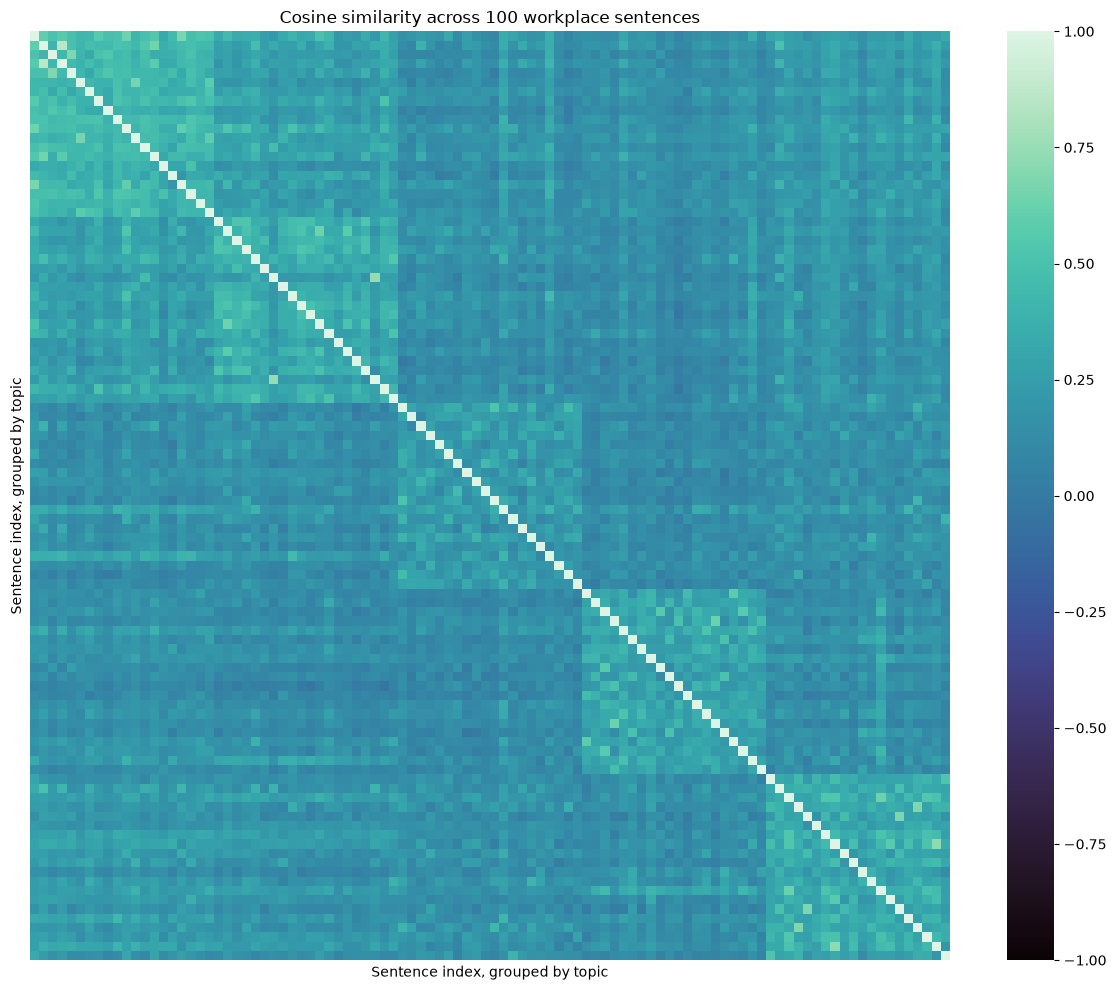

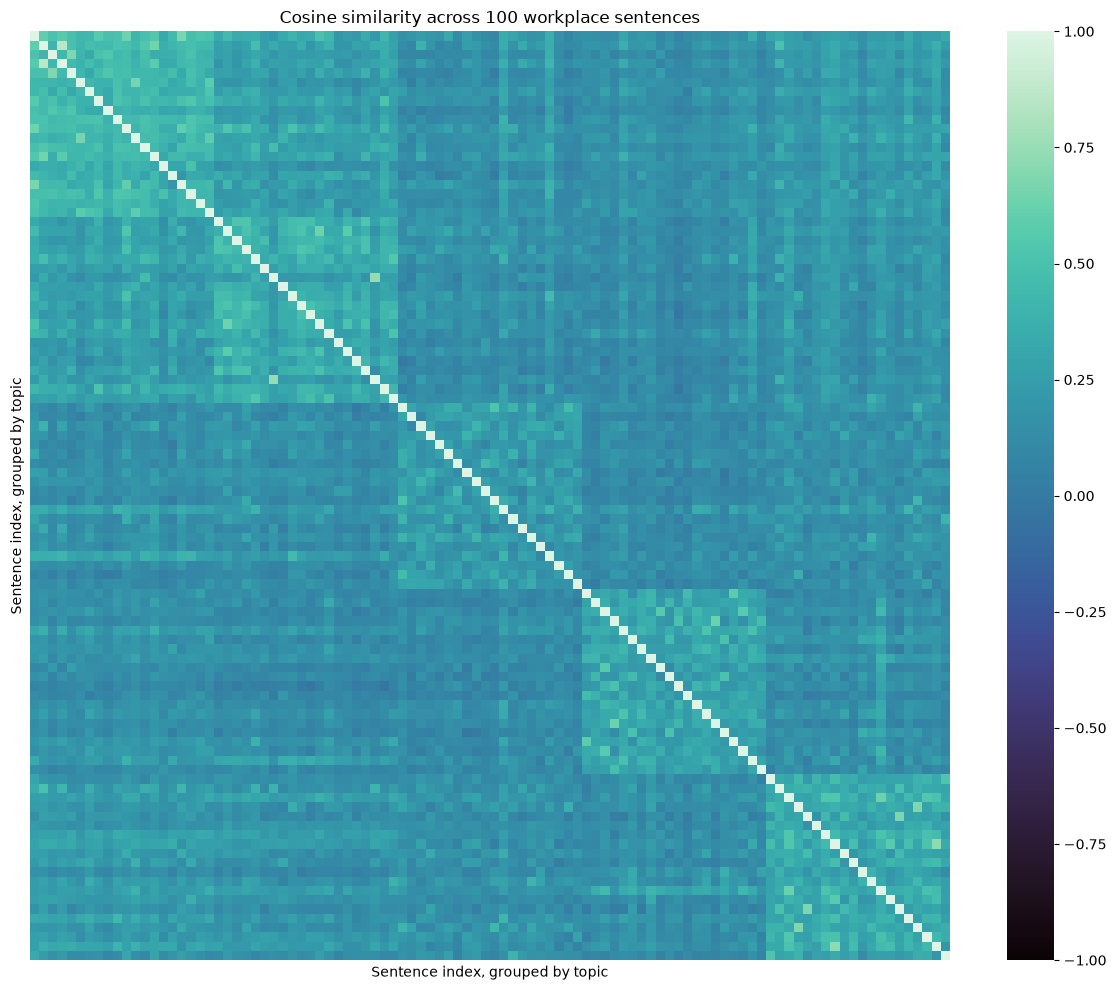

In [7]:
embeddings = np.asarray(exercise.embedding_model.embed_documents(texts), dtype=float)
exercise.embeddings = embeddings
print(f"Embedding array shape: {embeddings.shape}")
print(f"Shape dimensions: {embeddings.shape[0]} rows = sentences; {embeddings.shape[1]} columns = embedding features.")

similarity_matrix = cosine_similarity(embeddings)
print(f"Cosine similarity matrix shape: {similarity_matrix.shape}")
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(similarity_matrix, cmap="mako", vmin=-1, vmax=1, xticklabels=False, yticklabels=False, ax=ax)
ax.set(title="Cosine similarity across 100 workplace sentences", xlabel="Sentence index, grouped by topic", ylabel="Sentence index, grouped by topic")
fig.tight_layout()
fig.savefig(VECTOR_DIR / "cosine_similarity_heatmap.png", dpi=160)
fig

In [8]:
def search(query, k=5):
    return exercise.search(query, k=k)

queries = [
    "How do I ask for time off next month?",
    "Why has my paycheck not arrived?",
    "I cannot connect to the company network.",
    "What vegetarian options are available for lunch?",
    "How can I change a flight for a work trip?",
    "Where can I update my bank details?",
    "Can I take a day off for a medical appointment?",
    "Who can help me install approved software?",
    "Can the office provide gluten-free catering?",
    "Which receipts do I need after traveling for work?",
]
for query in queries:
    print(f"\nQuery: {query}")
    for sentence, score, cluster in search(query, k=5):
        print(f"  [{score:.3f}] ({cluster}) {sentence}")


Query: How do I ask for time off next month?
  [0.537] (leave policy) Tell your manager when you need an unexpected personal day.
  [0.475] (leave policy) Employees should give two weeks notice for planned leave.
  [0.445] (leave policy) Submit a doctor's note when HR requests documentation for sick leave.
  [0.432] (leave policy) New employees accrue vacation time each month.
  [0.428] (leave policy) The manager approves annual leave after checking team coverage.

Query: Why has my paycheck not arrived?
  [0.565] (payroll) Contact payroll if your salary deposit is missing.
  [0.522] (payroll) Contractors submit invoices instead of receiving employee paychecks.
  [0.519] (payroll) Paychecks are deposited into the bank account on file.
  [0.483] (payroll) Monthly pay statements are available online after payday.
  [0.439] (payroll) A late timesheet can delay payment for recorded hours.

Query: I cannot connect to the company network.
  [0.370] (IT support) The help desk can troubleshoo

In [9]:
probes = [
    ("What is policy HR-114-B?", "leave policy", "Policy HR-114-B says unused leave does not carry forward.", "An identifier has little semantic meaning; exact-term search can match it directly."),
    ("leave that is not carried forward", "leave policy", "Policy HR-114-B says unused leave does not carry forward.", "Negation may move a vector only slightly, leaving the opposite carryover statement nearby."),
    ("claims above 50,000", "payroll", "Claims above 50,000 dollars require finance director approval.", "An embedding does not perform arithmetic or guarantee exact threshold comparisons."),
    ("Who manages reservations in SkyTrail?", "travel", "SkyTrail is the company portal for managing business flight reservations.", "A rare product name may have little learned meaning; keyword search can use the exact string."),
    ("Does the manager reject annual leave after checking team coverage?", "leave policy", "The manager rejects annual leave after checking team coverage.", "Approve and reject sentences share nearly all words despite opposite decisions."),
    ("I need a day off after my flight and also need reimbursement for the trip.", "leave policy", "Tell your manager when you need an unexpected personal day.", "Mixed leave and travel intent made embeddings favor a travel reimbursement sentence."),
    ("My payroll login is broken; who can reset it?", "IT support", "Reset your network password from the account recovery page.", "Payroll context pulled the vector result toward a salary deposit instead of account recovery."),
    ("I am going on leave; where do I submit reimbursement for flights?", "leave policy", "Policy HR-114-B says unused leave does not carry forward.", "Travel reimbursement wording dominated the leave-policy intent."),
]
for query, expected_cluster, expected_text, explanation in probes:
    vector_text, vector_score, vector_cluster = search(query, k=1)[0]
    lexical_results = exercise.keyword_search(query, k=1)
    lexical_text = lexical_results[0][0] if lexical_results else "No keyword match"
    print(f"\nQuery: {query}")
    print(f"Expected ({expected_cluster}): {expected_text}")
    print(f"Embedding ({vector_cluster}, cosine={vector_score:.3f}): {vector_text}")
    print(f"BM25 keyword: {lexical_text}")
    print(f"What broke: {explanation}")
    if vector_text != expected_text and lexical_text == expected_text:
        print("Keyword search would have got this; embeddings did not.")


Query: What is policy HR-114-B?
Expected (leave policy): Policy HR-114-B says unused leave does not carry forward.
Embedding (leave policy, cosine=0.551): Policy HR-114-B says unused leave does not carry forward.
BM25 keyword: Policy HR-114-B says unused leave does not carry forward.
What broke: An identifier has little semantic meaning; exact-term search can match it directly.

Query: leave that is not carried forward
Expected (leave policy): Policy HR-114-B says unused leave does not carry forward.
Embedding (leave policy, cosine=0.508): Policy HR-114-B says unused leave does not carry forward.
BM25 keyword: Policy HR-114-B says unused leave does not carry forward.
What broke: Negation may move a vector only slightly, leaving the opposite carryover statement nearby.

Query: claims above 50,000
Expected (payroll): Claims above 50,000 dollars require finance director approval.
Embedding (payroll, cosine=0.573): Claims above 50,000 dollars require finance director approval.
BM25 keywor

In [ ]:
coordinates = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=42).fit_transform(embeddings)
fig, ax = plt.subplots(figsize=(10, 8))
palette = dict(zip(exercise.SENTENCES_BY_CLUSTER, sns.color_palette("colorblind", 5)))
cluster_array = np.asarray(clusters)
for cluster, color in palette.items():
    mask = cluster_array == cluster
    ax.scatter(coordinates[mask, 0], coordinates[mask, 1], label=cluster, color=color, alpha=0.8, s=55)
ax.set(title="t-SNE view of workplace sentence embeddings", xlabel="t-SNE dimension 1", ylabel="t-SNE dimension 2")
ax.legend(title="Topic")
fig.tight_layout()
fig.savefig(VECTOR_DIR / "tsne_clusters.png", dpi=160)
fig